# Adaptive calibrated GRAPE

This notebook is the alternative to the RBF residual notebook.

The RBF approach tried to learn an arbitrary correction over the 80-dimensional pulse vector. The latest runs suggest that this is not the right statistical object: the correction is dynamical and physical, while the RBF only sees final scalar rewards.

Here we instead try **closed-loop calibrated GRAPE**:

```text
binary measurements -> fit physical nuisance parameters -> run GRAPE on calibrated model -> measure again
```

The nuisance parameters are low-dimensional and physically meaningful: detunings, chi offset, cavity self-Kerr, drive scale/phase, and lifetime scale factors. This should generalize much better than an 80D local interpolator.


In [2]:
from dataclasses import replace

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from hybrid_residual_grape import (
    FockPhysicsModel,
    HybridGrapeConfig,
    PhysicalCalibrationConfig,
    PhysicsParams,
    RBFResidualConfig,
    SimulationConfig,
    adaptive_shot_counts,
    append_dataset,
    beta_normal_lower_bound,
    calibration_parameter_summary,
    empty_rbf_model,
    fit_physical_parameters,
    make_local_experiment_batch,
    optimize_hybrid_grape,
    params_from_calibration_raw,
    physical_parameter_names,
    physical_parameter_size,
    sample_binomial_measurements,
)
from hybrid_residual_grape.config import (
    khz_to_rad_per_us,
    qubit_t1_us,
    qubit_t2_us,
    storage_t1_us,
    storage_t2_us,
)

jax.config.update("jax_enable_x64", True)


## Setup

There are three models in this notebook:

1. `physics_model`: the deliberately incomplete nominal model used for the pure-GRAPE baseline.
2. `calibration_model`: a model object used to evaluate many candidate physical parameter sets. It has the same Hilbert space and basis, but the parameters are passed explicitly.
3. `true_model`: only for the simulated experiment. In real hardware this would be replaced by the OPX photon-number test.

The hidden true model includes effects that the nominal pure-GRAPE baseline omits: cavity self-Kerr, small detunings, drive calibration error, phase error, and T1/T2 decay/dephasing.


In [3]:
seed = 1234
key = jax.random.key(seed)

q = SimulationConfig(
    n_cav=25,
    target_n=2,
    initial_cavity_n=0,
    initial_qubit_state=0,
    t_drive=1.408,
    ndt_drive=80,
    num_coeffs=20,
    spline_degree=2,
    spline_skip_left=2,
    spline_skip_right=2,
    param_clip=2.0,
)

config_params = PhysicsParams()

# Deliberately incomplete nominal model: no cavity self-Kerr and no decoherence.
nominal_params = replace(
    config_params,
    cavity_self_kerr=0.0,
    qubit_t1_us=None,
    qubit_t2_us=None,
    cavity_t1_us=None,
    cavity_t2_us=None,
)
physics_model = FockPhysicsModel(q, nominal_params)

# Reference values available from configuration.json. Calibration starts here.
reference_params = replace(
    nominal_params,
    qubit_t1_us=qubit_t1_us(),
    qubit_t2_us=qubit_t2_us(),
    cavity_t1_us=storage_t1_us(),
    cavity_t2_us=storage_t2_us(),
)
calibration_model = FockPhysicsModel(q, reference_params)

# Hidden true experiment for this notebook only.
lifetime_scale = 0.75
true_params = replace(
    config_params,
    chi=config_params.chi + khz_to_rad_per_us(3.0),
    cavity_self_kerr=config_params.cavity_self_kerr + khz_to_rad_per_us(0.12),
    cavity_detuning=khz_to_rad_per_us(5.0),
    qubit_detuning=khz_to_rad_per_us(-5.0),
    mu_qub=config_params.mu_qub * 1.010,
    mu_cav=config_params.mu_cav * 0.988,
    cavity_phase=0.025,
    qubit_t1_us=lifetime_scale * qubit_t1_us(),
    qubit_t2_us=lifetime_scale * qubit_t2_us(),
    cavity_t1_us=lifetime_scale * storage_t1_us(),
    cavity_t2_us=lifetime_scale * storage_t2_us(),
)
true_model = FockPhysicsModel(q, true_params)

print("parameter size:", physics_model.parameter_size)
print("basis endpoint max:", float(jnp.max(jnp.abs(physics_model.bsplines_edges[:, [0, -1]]))))
print("max active B-splines:", int(jnp.max(jnp.sum(physics_model.bsplines_mids > 1e-12, axis=0))))
print("nominal chi [rad/us]:", nominal_params.chi)
print("true chi [rad/us]:", true_params.chi)
print("nominal cavity self Kerr [rad/us]:", nominal_params.cavity_self_kerr)
print("true cavity self Kerr [rad/us]:", true_params.cavity_self_kerr)
print("reference qubit T1/T2 [us]:", reference_params.qubit_t1_us, reference_params.qubit_t2_us)
print("true qubit T1/T2 [us]:", true_params.qubit_t1_us, true_params.qubit_t2_us)
print("reference cavity T1/T2 [us]:", reference_params.cavity_t1_us, reference_params.cavity_t2_us)
print("true cavity T1/T2 [us]:", true_params.cavity_t1_us, true_params.cavity_t2_us)


parameter size: 80
basis endpoint max: 0.0
max active B-splines: 3
nominal chi [rad/us]: 4.145440537691808
true chi [rad/us]: 4.164290093613347
nominal cavity self Kerr [rad/us]: 0.0
true cavity self Kerr [rad/us]: -0.0037768226881456494
reference qubit T1/T2 [us]: 43.5 32.5
true qubit T1/T2 [us]: 32.625 24.375
reference cavity T1/T2 [us]: 226.2 334.6
true cavity T1/T2 [us]: 169.64999999999998 250.95000000000002


### Unitary vs non-unitary paths

The simulator switches automatically based on collapse operators:

- `0` collapse operators means pure-state unitary evolution;
- nonzero collapse operators means density-matrix Lindblad evolution with T1/T2.

In this notebook the nominal physics-only baseline is intentionally unitary, but the hidden experiment, oracle true-GRAPE, parameter fitting, and calibrated-GRAPE loop are non-unitary whenever T1/T2 are enabled.


In [ ]:
print("nominal model collapse operators:", len(physics_model.collapse_ops), "-> unitary physics-only GRAPE")
print("calibration/reference collapse operators:", len(calibration_model.collapse_ops), "-> non-unitary parameter fitting")
print("true experiment collapse operators:", len(true_model.collapse_ops), "-> non-unitary measurements and oracle true-GRAPE")


## Hyperparameters

The calibrated model is slower than the pure unitary model because it can include density-matrix T1/T2 dynamics. Keep these values modest for a first DGX run, then increase them once the workflow is stable.

The key difference from the RBF notebook is adaptive shots: promising pulses get more repetitions, because near high fidelity the binomial noise can be comparable to the remaining infidelity.


In [4]:
rbf_config = RBFResidualConfig(max_centers=1)
empty_residual = empty_rbf_model(physics_model.parameter_size, rbf_config)

physics_only_config = HybridGrapeConfig(
    maxiter=320,
    memory_size=20,
    noise_samples=1,
    control_noise_std=0.0,
    residual_support_penalty=0.0,
    residual_size_penalty=0.0,
    amplitude_l2=5e-5,
    smoothness_l2=5e-5,
    param_clip=q.param_clip,
    grad_clip_norm=30.0,
)

calibrated_grape_config = HybridGrapeConfig(
    maxiter=180,
    memory_size=15,
    noise_samples=3,
    control_noise_std=0.010,
    residual_support_penalty=0.0,
    residual_size_penalty=0.0,
    amplitude_l2=5e-5,
    smoothness_l2=5e-5,
    param_clip=q.param_clip,
    grad_clip_norm=30.0,
)

oracle_config = replace(
    calibrated_grape_config,
    maxiter=160,
    noise_samples=1,
    control_noise_std=0.0,
)

calibration_config = PhysicalCalibrationConfig(
    fit_decoherence=True,
    fit_steps=80,
    learning_rate=0.035,
    prior_strength=2e-3,
    max_chi_offset_khz=8.0,
    max_cavity_detuning_khz=20.0,
    max_qubit_detuning_khz=20.0,
    max_cavity_self_kerr_abs_khz=2.0,
    max_drive_scale_fraction=0.06,
    max_cavity_phase_rad=0.10,
    max_lifetime_log_scale=0.70,
)

rounds = 14
experiment_batch_size = 8
local_noise_std = 0.022
calibration_max_points = 80

low_shots = 1000
medium_shots = 4000
high_shots = 12000
shot_time_us = 400.0

print("calibrated parameter names:", physical_parameter_names(calibration_config))
print("calibration parameter size:", physical_parameter_size(calibration_config))
print("low/medium/high shots:", low_shots, medium_shots, high_shots)
print("max shots per round [if all high]:", experiment_batch_size * high_shots)
print("max measurement time per round [s]:", experiment_batch_size * high_shots * shot_time_us * 1e-6)


calibrated parameter names: ('chi_offset', 'cavity_detuning', 'qubit_detuning', 'cavity_self_kerr', 'mu_qub_scale', 'mu_cav_scale', 'cavity_phase', 'qubit_T1_scale', 'qubit_T2_scale', 'cavity_T1_scale', 'cavity_T2_scale')
calibration parameter size: 11
low/medium/high shots: 1000 4000 12000
max shots per round [if all high]: 96000
max measurement time per round [s]: 38.4


## Experiment hook

The simulated experiment accepts one shot count per pulse. On hardware this should become the OPX call: each row of `controls` is sent as one pulse packet, played `shots[i]` times, and returns `successes[i]`.


In [5]:
def measure_on_experiment(controls, key, shots):
    return sample_binomial_measurements(
        true_model,
        controls,
        key,
        shots=shots,
    )


## Baselines: nominal GRAPE and oracle true-GRAPE

The nominal baseline is the fair pure-GRAPE comparison:

```text
optimize on incomplete nominal physics -> evaluate once on hidden true experiment
```

The oracle baseline is impossible on hardware, but crucial in simulation:

```text
optimize directly on the hidden true model
```

If oracle true-GRAPE cannot beat the nominal baseline, then no measurement learner can do much. If oracle true-GRAPE is much better, then the gap is learnable and the question becomes how to identify the right model from binary data.


In [6]:
key, init_key = jax.random.split(key)
initial_controls = 0.02 * jax.random.normal(init_key, (physics_model.parameter_size,))
initial_controls = jnp.clip(initial_controls, -q.param_clip, q.param_clip)

physics_only_restarts = 6
key, restart_key = jax.random.split(key)
restart_controls = 0.04 * jax.random.normal(
    restart_key,
    (physics_only_restarts, physics_model.parameter_size),
)
restart_controls = restart_controls.at[0].set(initial_controls)
restart_controls = jnp.clip(restart_controls, -q.param_clip, q.param_clip)

physics_only_candidates = []
key, baseline_key = jax.random.split(key)
baseline_keys = jax.random.split(baseline_key, physics_only_restarts)

for restart_index in tqdm(range(physics_only_restarts), desc="nominal physics-only GRAPE"):
    candidate, history, summary, _ = optimize_hybrid_grape(
        physics_model,
        empty_residual,
        restart_controls[restart_index],
        baseline_keys[restart_index],
        physics_only_config,
    )
    physics_only_candidates.append(candidate)

physics_only_candidates = jnp.stack(physics_only_candidates)
physics_only_pred_all = physics_model.population_probability(physics_only_candidates)
physics_only_true_all = true_model.population_probability(physics_only_candidates)
physics_only_best_idx = int(jnp.argmax(physics_only_pred_all))
physics_only_controls = physics_only_candidates[physics_only_best_idx]
physics_only_pred = physics_only_pred_all[physics_only_best_idx]
physics_only_true = physics_only_true_all[physics_only_best_idx]

print("physics-only best restart:", physics_only_best_idx)
print("physics-only nominal P_n:", float(physics_only_pred))
print("physics-only true diagnostic P_n:", float(physics_only_true))
print("all restart nominal P_n:", jax.device_get(physics_only_pred_all))
print("all restart true P_n:", jax.device_get(physics_only_true_all))


nominal physics-only GRAPE: 100%|██████████| 6/6 [04:54<00:00, 49.04s/it]


physics-only best restart: 3
physics-only nominal P_n: 0.9999196456308289
physics-only true diagnostic P_n: 0.9516725300367034
all restart nominal P_n: [0.         0.99989979 0.99214838 0.99991965 0.99884653 0.9997453 ]
all restart true P_n: [0.         0.95321132 0.67978132 0.95167253 0.87973151 0.83381784]


In [7]:
run_oracle_true_grape = True
oracle_true = jnp.nan
oracle_controls = None

if run_oracle_true_grape:
    oracle_restarts = 2
    key, oracle_key = jax.random.split(key)
    oracle_restart_controls = jnp.concatenate(
        [
            physics_only_controls[None, :],
            0.04 * jax.random.normal(oracle_key, (oracle_restarts - 1, physics_model.parameter_size)),
        ],
        axis=0,
    )
    oracle_restart_controls = jnp.clip(oracle_restart_controls, -q.param_clip, q.param_clip)
    key, oracle_key = jax.random.split(key)
    oracle_keys = jax.random.split(oracle_key, oracle_restarts)
    oracle_candidates = []

    for restart_index in tqdm(range(oracle_restarts), desc="oracle true-GRAPE"):
        candidate, history, summary, _ = optimize_hybrid_grape(
            true_model,
            empty_residual,
            oracle_restart_controls[restart_index],
            oracle_keys[restart_index],
            oracle_config,
        )
        oracle_candidates.append(candidate)

    oracle_candidates = jnp.stack(oracle_candidates)
    oracle_true_all = true_model.population_probability(oracle_candidates)
    oracle_best_idx = int(jnp.argmax(oracle_true_all))
    oracle_controls = oracle_candidates[oracle_best_idx]
    oracle_true = oracle_true_all[oracle_best_idx]
    print("oracle true-GRAPE best restart:", oracle_best_idx)
    print("oracle true-GRAPE true P_n:", float(oracle_true))
    print("all oracle true P_n:", jax.device_get(oracle_true_all))
else:
    print("Oracle true-GRAPE skipped.")


oracle true-GRAPE: 100%|██████████| 2/2 [01:08<00:00, 34.03s/it]


oracle true-GRAPE best restart: 0
oracle true-GRAPE true P_n: 0.9616477816727929
all oracle true P_n: [0.96164778 0.95389611]


## Closed-loop calibrated GRAPE

Each round:

1. Fit physical nuisance parameters by binomial negative log-likelihood.
2. Build a calibrated `FockPhysicsModel` from those parameters.
3. Run GRAPE on the calibrated model, warm-started from the best known pulse.
4. Measure the proposed pulse and local variants.
5. Use adaptive shots: high predicted fidelity gets more measurements.
6. Select the best pulse by a lower confidence bound, not by lucky raw success rate.

The lower confidence bound matters near high fidelity. It prevents a pulse with a lucky binomial fluctuation from becoming the new champion too easily.


In [8]:
def select_calibration_data(controls, successes, shots, max_points):
    if controls.shape[0] <= max_points:
        return controls, successes, shots
    return controls[-max_points:], successes[-max_points:], shots[-max_points:]


def log_infidelity(probability):
    return -jnp.log10(jnp.maximum(1.0 - probability, 1e-8))


calibration_raw = jnp.zeros((physical_parameter_size(calibration_config),), dtype=jnp.float64)
calibrated_params = params_from_calibration_raw(
    calibration_raw,
    nominal_params,
    reference_params,
    calibration_config,
)

best_controls = physics_only_controls
best_measured = float(physics_only_true)  # diagnostic prior until real shots are taken
best_lcb = -1.0
best_true_diagnostic = float(physics_only_true)

dataset_controls = None
dataset_successes = None
dataset_shots = None
dataset_nominal_probability = None

progress_rows = []
param_history = []
calibration_histories = []
total_measurements = 0

pbar = tqdm(range(rounds), desc="adaptive calibrated GRAPE")

for round_index in pbar:
    if dataset_controls is not None and dataset_controls.shape[0] >= 4:
        fit_controls, fit_successes, fit_shots = select_calibration_data(
            dataset_controls,
            dataset_successes,
            dataset_shots,
            calibration_max_points,
        )
        calibration_raw, calibrated_params, fit_history = fit_physical_parameters(
            calibration_model,
            nominal_params,
            reference_params,
            fit_controls,
            fit_successes,
            fit_shots,
            initial_raw=calibration_raw,
            config=calibration_config,
        )
        calibration_histories.append(fit_history)
        fit_loss = float(fit_history[-1, 0])
        fit_nll = float(fit_history[-1, 1])
    else:
        fit_loss = float("nan")
        fit_nll = float("nan")

    param_summary = calibration_parameter_summary(
        calibration_raw,
        calibrated_params,
        nominal_params,
        reference_params,
        calibration_config,
    )
    param_history.append(param_summary)

    calibrated_model = FockPhysicsModel(q, calibrated_params)
    proposed_controls, grape_history, grape_summary, key = optimize_hybrid_grape(
        calibrated_model,
        empty_residual,
        best_controls,
        key,
        calibrated_grape_config,
    )

    experiment_controls, key = make_local_experiment_batch(
        proposed_controls,
        key,
        batch_size=experiment_batch_size,
        noise_std=local_noise_std,
        param_clip=q.param_clip,
        include_center=True,
    )

    predicted_probability = calibrated_model.population_probability(experiment_controls)
    shot_counts = adaptive_shot_counts(
        predicted_probability,
        low_shots=low_shots,
        medium_shots=medium_shots,
        high_shots=high_shots,
        medium_threshold=0.85,
        high_threshold=0.94,
    )
    shot_counts = shot_counts.at[0].set(jnp.maximum(shot_counts[0], medium_shots))

    successes, measured_shots, true_probability, key = measure_on_experiment(
        experiment_controls,
        key,
        shots=shot_counts,
    )

    nominal_probability = physics_model.population_probability(experiment_controls)
    dataset_controls, dataset_successes, dataset_shots, dataset_nominal_probability = append_dataset(
        dataset_controls,
        dataset_successes,
        dataset_shots,
        dataset_nominal_probability,
        experiment_controls,
        successes,
        measured_shots,
        nominal_probability,
    )

    total_measurements += int(jnp.sum(measured_shots))
    measured_probability = successes / measured_shots
    lower_bound = beta_normal_lower_bound(successes, measured_shots, z=2.0)
    best_in_batch = int(jnp.argmax(lower_bound))

    if float(lower_bound[best_in_batch]) > best_lcb:
        best_lcb = float(lower_bound[best_in_batch])
        best_measured = float(measured_probability[best_in_batch])
        best_true_diagnostic = float(true_probability[best_in_batch])
        best_controls = experiment_controls[best_in_batch]
    elif float(lower_bound[0]) > best_lcb - 0.02:
        # Warm start from the center if it is statistically close to the champion.
        best_controls = proposed_controls

    progress_rows.append(
        jnp.array(
            [
                float(total_measurements),
                best_measured,
                best_lcb,
                best_true_diagnostic,
                float(measured_probability[0]),
                float(lower_bound[0]),
                float(true_probability[0]),
                float(predicted_probability[0]),
                fit_loss,
                fit_nll,
                float(dataset_controls.shape[0]),
                float(jnp.sum(measured_shots)),
            ]
        )
    )

    pbar.set_postfix(
        {
            "best_lcb": f"{best_lcb:.3f}",
            "best_true": f"{best_true_diagnostic:.4f}",
            "center": f"{float(measured_probability[0]):.3f}",
            "pred": f"{float(predicted_probability[0]):.3f}",
            "shots": int(jnp.sum(measured_shots)),
        }
    )

progress = jnp.stack(progress_rows) if progress_rows else jnp.zeros((0, 12))
print("total binary measurements:", total_measurements)
print("best measured P_n:", best_measured)
print("best lower confidence bound:", best_lcb)
print("best true diagnostic P_n:", best_true_diagnostic)
print("last calibrated parameters:")
for key_name, value in param_history[-1].items():
    print(f"  {key_name}: {value:.6g}")


adaptive calibrated GRAPE: 100%|██████████| 14/14 [14:18<00:00, 61.33s/it, best_lcb=0.961, best_true=0.9627, center=0.957, pred=0.955, shots=37000]

total binary measurements: 496000
best measured P_n: 0.9642499685287476
best lower confidence bound: 0.9608200788497925
best true diagnostic P_n: 0.9627179272711044
last calibrated parameters:
  chi_offset_khz: 0.0514809
  cavity_detuning_khz: 0.763864
  qubit_detuning_khz: 0.223832
  cavity_self_kerr_khz: 0.00309489
  mu_qub: 20.1042
  mu_cav: 19.8204
  cavity_phase_rad: -4.99571e-05
  qubit_T1_us: 41.6395
  qubit_T2_us: 27.5093
  cavity_T1_us: 247.957
  cavity_T2_us: 258.334
  qubit_T1_scale: 0.95723
  qubit_T2_scale: 0.846439
  cavity_T1_scale: 1.09619
  cavity_T2_scale: 0.772068


## Progress plots

Compare against both baselines:

- nominal physics-only GRAPE tells us what the incomplete model achieves;
- oracle true-GRAPE tells us the simulation-only ceiling;
- calibrated GRAPE tells us what we can recover from binary measurements.


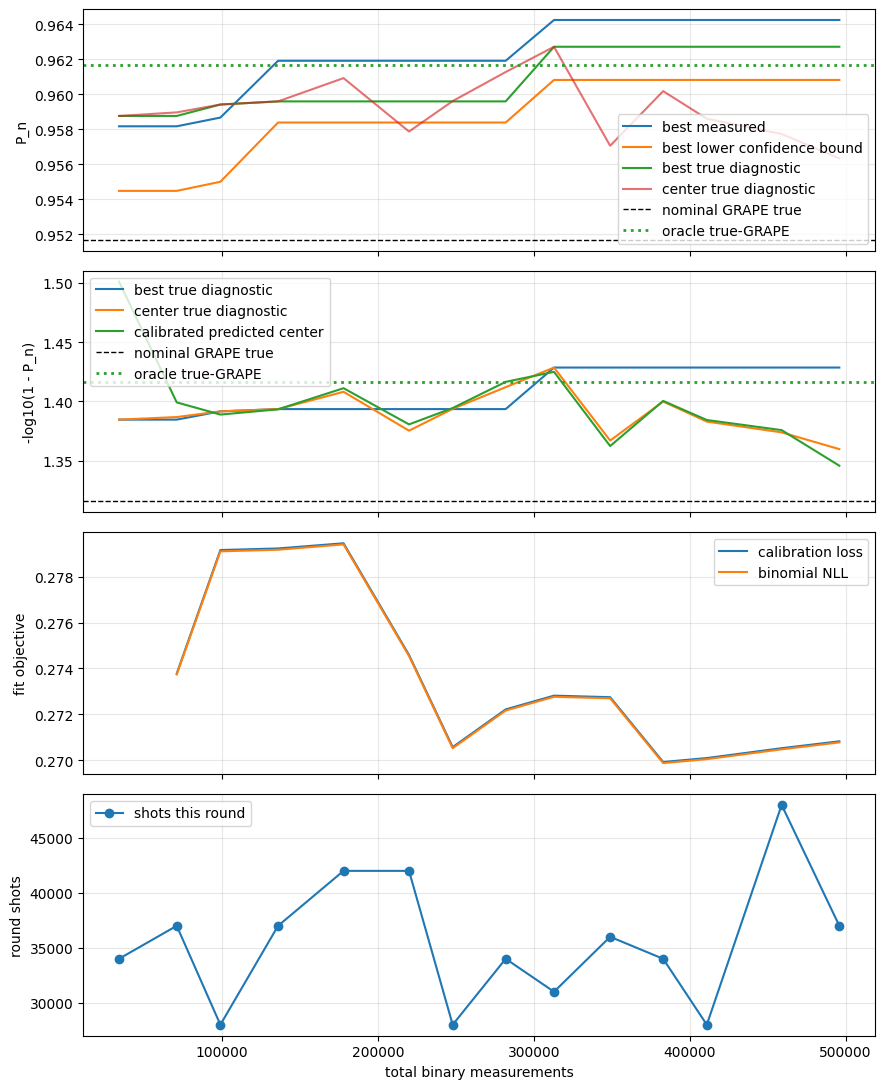

In [9]:
if len(progress_rows):
    progress = jnp.stack(progress_rows)
    fig, axes = plt.subplots(4, 1, figsize=(9, 11), sharex=True)

    axes[0].plot(progress[:, 0], progress[:, 1], label="best measured")
    axes[0].plot(progress[:, 0], progress[:, 2], label="best lower confidence bound")
    axes[0].plot(progress[:, 0], progress[:, 3], label="best true diagnostic")
    axes[0].plot(progress[:, 0], progress[:, 6], label="center true diagnostic", alpha=0.65)
    axes[0].axhline(float(physics_only_true), color="black", linestyle="--", linewidth=1, label="nominal GRAPE true")
    if not bool(jnp.isnan(oracle_true)):
        axes[0].axhline(float(oracle_true), color="tab:green", linestyle=":", linewidth=2, label="oracle true-GRAPE")
    axes[0].set_ylabel("P_n")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    axes[1].plot(progress[:, 0], log_infidelity(progress[:, 3]), label="best true diagnostic")
    axes[1].plot(progress[:, 0], log_infidelity(progress[:, 6]), label="center true diagnostic")
    axes[1].plot(progress[:, 0], log_infidelity(progress[:, 7]), label="calibrated predicted center")
    axes[1].axhline(float(log_infidelity(physics_only_true)), color="black", linestyle="--", linewidth=1, label="nominal GRAPE true")
    if not bool(jnp.isnan(oracle_true)):
        axes[1].axhline(float(log_infidelity(oracle_true)), color="tab:green", linestyle=":", linewidth=2, label="oracle true-GRAPE")
    axes[1].set_ylabel("-log10(1 - P_n)")
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    axes[2].plot(progress[:, 0], progress[:, 8], label="calibration loss")
    axes[2].plot(progress[:, 0], progress[:, 9], label="binomial NLL")
    axes[2].set_ylabel("fit objective")
    axes[2].grid(True, alpha=0.3)
    axes[2].legend()

    axes[3].plot(progress[:, 0], progress[:, 11], marker="o", label="shots this round")
    axes[3].set_xlabel("total binary measurements")
    axes[3].set_ylabel("round shots")
    axes[3].grid(True, alpha=0.3)
    axes[3].legend()

    plt.tight_layout()
    plt.show()
else:
    print("Run the loop first.")


## Parameter calibration traces

These plots are simulation diagnostics. In a real experiment we would not know the true values, but in the notebook they tell us whether the binary data is actually identifying the physical mismatch.


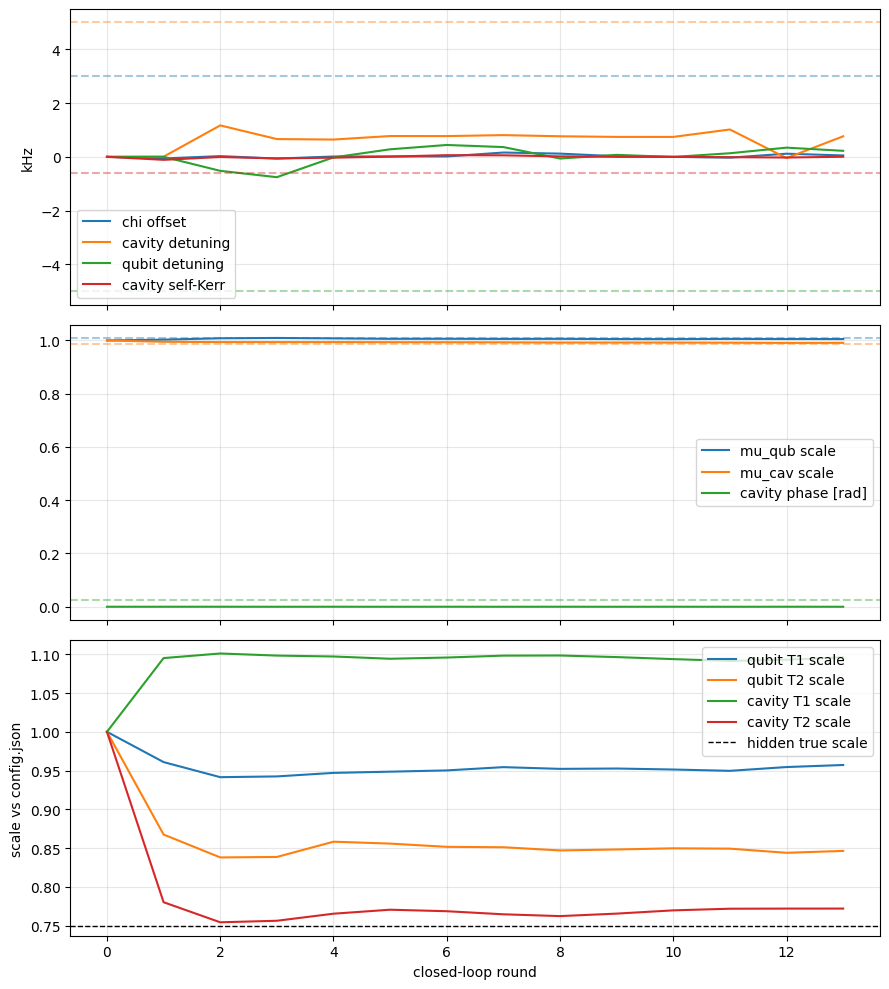

In [13]:
if param_history:
    xs = jnp.arange(len(param_history))

    chi = jnp.array([row["chi_offset_khz"] for row in param_history])
    cav_det = jnp.array([row["cavity_detuning_khz"] for row in param_history])
    qub_det = jnp.array([row["qubit_detuning_khz"] for row in param_history])
    kerr = jnp.array([row["cavity_self_kerr_khz"] for row in param_history])
    mu_q = jnp.array([row["mu_qub"] for row in param_history])
    mu_c = jnp.array([row["mu_cav"] for row in param_history])
    phase = jnp.array([row["cavity_phase_rad"] for row in param_history])
    qt1 = jnp.array([row["qubit_T1_scale"] for row in param_history])
    qt2 = jnp.array([row["qubit_T2_scale"] for row in param_history])
    ct1 = jnp.array([row["cavity_T1_scale"] for row in param_history])
    ct2 = jnp.array([row["cavity_T2_scale"] for row in param_history])

    true_chi_offset = (true_params.chi - nominal_params.chi) * 1000.0 / (2.0 * jnp.pi)
    true_kerr = true_params.cavity_self_kerr * 1000.0 / (2.0 * jnp.pi)
    true_cav_det = true_params.cavity_detuning * 1000.0 / (2.0 * jnp.pi)
    true_qub_det = true_params.qubit_detuning * 1000.0 / (2.0 * jnp.pi)

    fig, axes = plt.subplots(3, 1, figsize=(9, 10), sharex=True)

    axes[0].plot(xs, chi, label="chi offset")
    axes[0].plot(xs, cav_det, label="cavity detuning")
    axes[0].plot(xs, qub_det, label="qubit detuning")
    axes[0].plot(xs, kerr, label="cavity self-Kerr")
    axes[0].axhline(float(true_chi_offset), color="tab:blue", linestyle="--", alpha=0.4)
    axes[0].axhline(float(true_cav_det), color="tab:orange", linestyle="--", alpha=0.4)
    axes[0].axhline(float(true_qub_det), color="tab:green", linestyle="--", alpha=0.4)
    axes[0].axhline(float(true_kerr), color="tab:red", linestyle="--", alpha=0.4)
    axes[0].set_ylabel("kHz")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    axes[1].plot(xs, mu_q / nominal_params.mu_qub, label="mu_qub scale")
    axes[1].plot(xs, mu_c / nominal_params.mu_cav, label="mu_cav scale")
    axes[1].plot(xs, phase, label="cavity phase [rad]")
    axes[1].axhline(float(true_params.mu_qub / nominal_params.mu_qub), color="tab:blue", linestyle="--", alpha=0.4)
    axes[1].axhline(float(true_params.mu_cav / nominal_params.mu_cav), color="tab:orange", linestyle="--", alpha=0.4)
    axes[1].axhline(float(true_params.cavity_phase), color="tab:green", linestyle="--", alpha=0.4)
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    axes[2].plot(xs, qt1, label="qubit T1 scale")
    axes[2].plot(xs, qt2, label="qubit T2 scale")
    axes[2].plot(xs, ct1, label="cavity T1 scale")
    axes[2].plot(xs, ct2, label="cavity T2 scale")
    axes[2].axhline(lifetime_scale, color="black", linestyle="--", linewidth=1, label="hidden true scale")
    axes[2].set_xlabel("closed-loop round")
    axes[2].set_ylabel("scale vs config.json")
    axes[2].grid(True, alpha=0.3)
    axes[2].legend()

    plt.tight_layout()
    plt.show()
else:
    print("Run the loop first.")


## Calibration diagnostic on the collected dataset

This is the analogue of the RBF diagnostic, but for physical calibration. The calibrated model should predict measured data better than the incomplete nominal model. If it does not, the physical parameter fit is not helping.


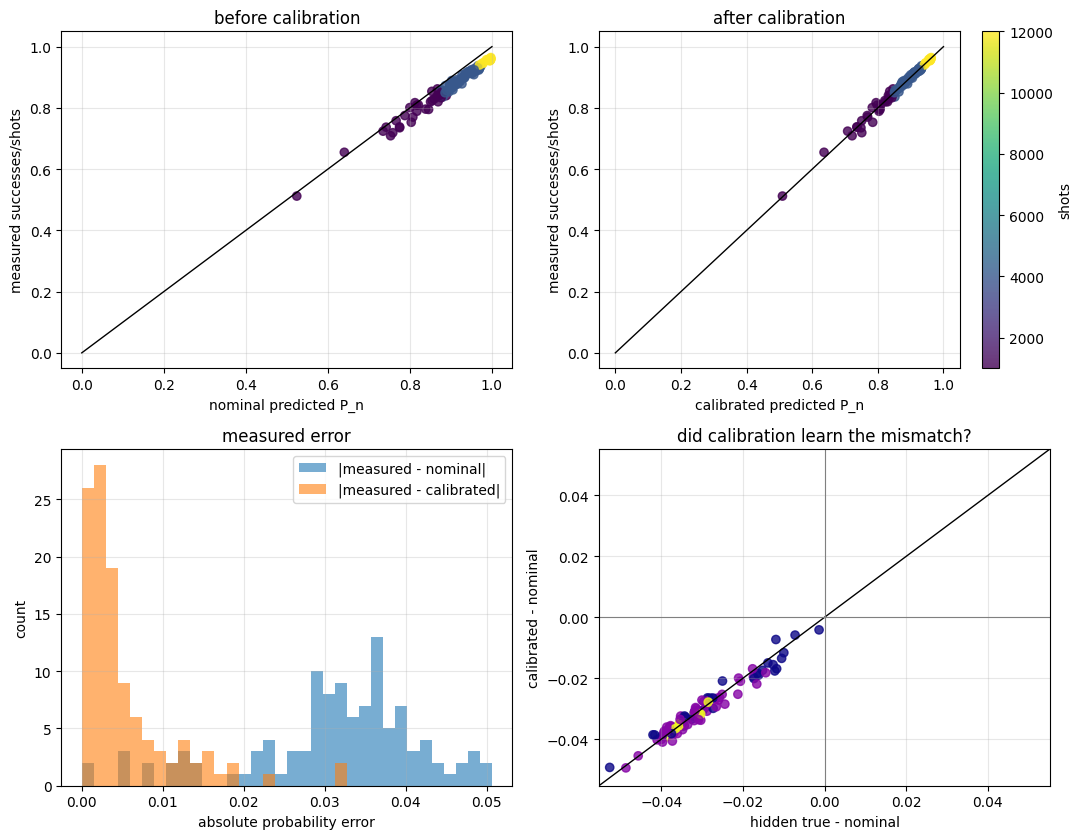

measured MAE nominal -> data: 0.03105728045271067
measured MAE calibrated -> data: 0.005279777971947975
hidden true MAE nominal -> true: 0.030557709567431524
hidden true MAE calibrated -> true: 0.0015413460303789453


In [14]:
if dataset_controls is not None and dataset_controls.shape[0] > 0:
    calibrated_model = FockPhysicsModel(q, calibrated_params)
    measured = dataset_successes / dataset_shots
    nominal_pred = physics_model.population_probability(dataset_controls)
    calibrated_pred = calibrated_model.population_probability(dataset_controls)
    true_diag = true_model.population_probability(dataset_controls)

    nominal_measured_mae = jnp.mean(jnp.abs(measured - nominal_pred))
    calibrated_measured_mae = jnp.mean(jnp.abs(measured - calibrated_pred))
    nominal_true_mae = jnp.mean(jnp.abs(true_diag - nominal_pred))
    calibrated_true_mae = jnp.mean(jnp.abs(true_diag - calibrated_pred))

    fig, axes = plt.subplots(2, 2, figsize=(11, 8.5))
    axes = axes.ravel()

    axes[0].scatter(nominal_pred, measured, c=dataset_shots, cmap="viridis", alpha=0.8)
    axes[0].plot([0, 1], [0, 1], color="black", linewidth=1)
    axes[0].set_xlabel("nominal predicted P_n")
    axes[0].set_ylabel("measured successes/shots")
    axes[0].set_title("before calibration")
    axes[0].grid(True, alpha=0.3)

    sc = axes[1].scatter(calibrated_pred, measured, c=dataset_shots, cmap="viridis", alpha=0.8)
    axes[1].plot([0, 1], [0, 1], color="black", linewidth=1)
    axes[1].set_xlabel("calibrated predicted P_n")
    axes[1].set_ylabel("measured successes/shots")
    axes[1].set_title("after calibration")
    axes[1].grid(True, alpha=0.3)
    fig.colorbar(sc, ax=axes[1], label="shots")

    bins = jnp.linspace(
        0.0,
        float(jnp.maximum(jnp.max(jnp.abs(measured - nominal_pred)), jnp.max(jnp.abs(measured - calibrated_pred)))) + 1e-6,
        35,
    )
    axes[2].hist(jax.device_get(jnp.abs(measured - nominal_pred)), bins=jax.device_get(bins), alpha=0.6, label="|measured - nominal|")
    axes[2].hist(jax.device_get(jnp.abs(measured - calibrated_pred)), bins=jax.device_get(bins), alpha=0.6, label="|measured - calibrated|")
    axes[2].set_xlabel("absolute probability error")
    axes[2].set_ylabel("count")
    axes[2].set_title("measured error")
    axes[2].grid(True, alpha=0.3)
    axes[2].legend()

    axes[3].scatter(true_diag - nominal_pred, calibrated_pred - nominal_pred, c=dataset_shots, cmap="plasma", alpha=0.8)
    lim = float(jnp.maximum(0.03, 1.05 * jnp.max(jnp.abs(jnp.concatenate([true_diag - nominal_pred, calibrated_pred - nominal_pred])))))
    axes[3].plot([-lim, lim], [-lim, lim], color="black", linewidth=1)
    axes[3].axhline(0, color="gray", linewidth=0.8)
    axes[3].axvline(0, color="gray", linewidth=0.8)
    axes[3].set_xlim(-lim, lim)
    axes[3].set_ylim(-lim, lim)
    axes[3].set_xlabel("hidden true - nominal")
    axes[3].set_ylabel("calibrated - nominal")
    axes[3].set_title("did calibration learn the mismatch?")
    axes[3].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print("measured MAE nominal -> data:", float(nominal_measured_mae))
    print("measured MAE calibrated -> data:", float(calibrated_measured_mae))
    print("hidden true MAE nominal -> true:", float(nominal_true_mae))
    print("hidden true MAE calibrated -> true:", float(calibrated_true_mae))
else:
    print("No dataset yet.")


## Export current best pulse

This is the best pulse selected by the lower confidence bound. In simulation we also print the hidden true diagnostic fidelity.


In [15]:
print("best_controls shape:", best_controls.shape)
print("max abs coefficient:", float(jnp.max(jnp.abs(best_controls))))
print("best measured P_n:", best_measured)
print("best lower confidence bound:", best_lcb)
print("best true diagnostic P_n:", best_true_diagnostic)
print("physics-only true diagnostic P_n:", float(physics_only_true))
if not bool(jnp.isnan(oracle_true)):
    print("oracle true-GRAPE diagnostic P_n:", float(oracle_true))


best_controls shape: (80,)
max abs coefficient: 1.3480670537409551
best measured P_n: 0.9642499685287476
best lower confidence bound: 0.9608200788497925
best true diagnostic P_n: 0.9627179272711044
physics-only true diagnostic P_n: 0.9516725300367034
oracle true-GRAPE diagnostic P_n: 0.9616477816727929
